In [1]:
%load_ext autoreload
%autoreload 2

from project_root import PROJECT_ROOT

import torchvision as tv
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
import enlighten
from pathlib import Path

pbar_manager = enlighten.get_manager()

In [2]:
torch.autograd.set_grad_enabled(False)

In [3]:
#########################################
# Check number of trainable params
base_model = tv.models.densenet121(weights=tv.models.DenseNet121_Weights.IMAGENET1K_V1)
# display(base_model)
layer_count = len(base_model.features)
print(f"Layer count: {layer_count}")

# Freeze layers
FREEZE_LAYER_COUNT = 10
for layer_idx in range(FREEZE_LAYER_COUNT):
    layer = base_model.features[layer_idx]
    params = list(layer.parameters())
    if not params:
        continue
    param_count = np.sum([p.data.numel() for p in params])
    for p in params:
        p.requires_grad = False
    print(f"Params for layer #{layer_idx}: {param_count}")

all_params = list(base_model.parameters())
# print(np.sum([p.data.numel() for p in all_params]))
active_params = [p.data.numel() for p in all_params if p.requires_grad]
print(f"Trainable params: {np.sum(active_params)}")

Layer count: 12
Params for layer #0: 9408
Params for layer #1: 128
Params for layer #4: 335040
Params for layer #5: 33280
Params for layer #6: 919680
Params for layer #7: 132096
Params for layer #8: 2837760
Params for layer #9: 526336
Trainable params: 3185128


/home/dherrera/data/elephants/training_data/zag_elp_cam_018/ZAG-ELP-CAM-018-25.01.2025-060848-100848_00276799_img.jpg


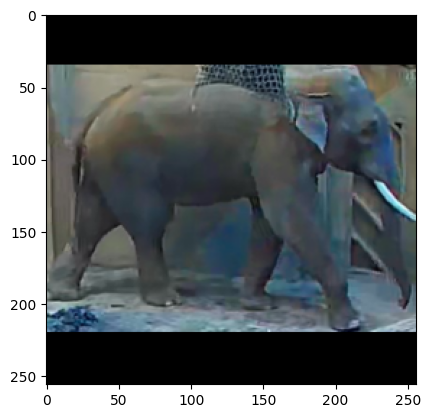

In [4]:
########################
# Test patch extraction
from scripts.datasets.segmentation_utils import bbox_from_mask
from scripts.datasets.identity_from_detection_ds import crop_bbox

data_root = Path("/home/dherrera/data/elephants")
src_root = data_root / "training_data"
files = list(src_root.glob("**/*_img.jpg"))
img_file = files[0]
print(img_file)
seg_file = Path(str(img_file).replace("_img.jpg", "_seg.png"))

# Load
im_color: np.ndarray = cv2.imread(img_file)
im_segmentation: np.ndarray = cv2.imread(seg_file, cv2.IMREAD_GRAYSCALE)

greys = [int(x) for x in np.unique(im_segmentation) if x != 0]
grey = greys[0]

mask = im_segmentation == grey
bbox = bbox_from_mask(mask)
crop = crop_bbox(im_color, bbox)
plt.imshow(crop)

In [5]:
########################
# Test trained model

USE_JIT = True
path = "/home/dherrera/git/zoo_vision/models/identity_1layer/dense121_c5_identity"
if USE_JIT:
    model = torch.jit.load(path + ".ptc")
    transforms = lambda x: x
else:
    model = tv.models.densenet121(num_classes=5)
    checkpoint = torch.load(path + ".pth", weights_only=False)
    model.load_state_dict(checkpoint["model"])

    transforms = tv.models.DenseNet121_Weights.IMAGENET1K_V1.transforms(antialias=True)
model.eval()
# model = tv.models.densenet121(tv.models.DenseNet121_Weights.IMAGENET1K_V1)
print(model)

RecursiveScriptModule(
  original_name=ModelWithTransforms
  (model): RecursiveScriptModule(
    original_name=DenseNet
    (features): RecursiveScriptModule(
      original_name=Sequential
      (conv0): RecursiveScriptModule(original_name=Conv2d)
      (norm0): RecursiveScriptModule(original_name=BatchNorm2d)
      (relu0): RecursiveScriptModule(original_name=ReLU)
      (pool0): RecursiveScriptModule(original_name=MaxPool2d)
      (denseblock1): RecursiveScriptModule(
        original_name=_DenseBlock
        (denselayer1): RecursiveScriptModule(
          original_name=_DenseLayer
          (norm1): RecursiveScriptModule(original_name=BatchNorm2d)
          (relu1): RecursiveScriptModule(original_name=ReLU)
          (conv1): RecursiveScriptModule(original_name=Conv2d)
          (norm2): RecursiveScriptModule(original_name=BatchNorm2d)
          (relu2): RecursiveScriptModule(original_name=ReLU)
          (conv2): RecursiveScriptModule(original_name=Conv2d)
        )
        (dense

In [6]:
if USE_JIT:
    transforms = lambda x: x
else:
    transforms = tv.models.DenseNet121_Weights.IMAGENET1K_V1.transforms(antialias=True)
print(transforms)

<function <lambda> at 0x7e13e849ce00>


/home/dherrera/data/elephants/identity/dataset/train/01_Chandra/ZAG-ELP-CAM-016-25.01.2025-060029-100029_00000000_img.jpg


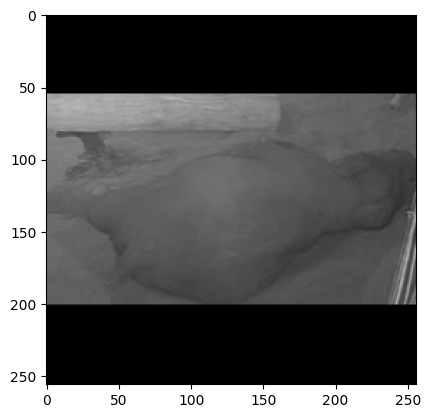

In [7]:
ds_path = Path("/home/dherrera/data/elephants/identity/dataset/train")
gt_class = "01_Chandra"

files = sorted(list((ds_path / gt_class).glob("*.jpg")))
# file = files[10]
file = Path(
    "/home/dherrera/data/elephants/identity/dataset/train/01_Chandra/ZAG-ELP-CAM-016-25.01.2025-060029-100029_00000000_img.jpg"
)
print(file)
im: np.ndarray = cv2.imread(file)
plt.imshow(im)

In [8]:
imt = transforms(torch.from_numpy(im.astype(np.float32) / 255).permute([2, 0, 1]))
imt = imt.unsqueeze(0)
result = model.forward(imt)
result

tensor([[-1.7052, -1.2501,  0.3028,  2.1914,  0.4689]])

{'01_Chandra': 0, '02_Indi': 1, '03_Fahra': 2, '04_Panang': 3, '05_Thai': 4}


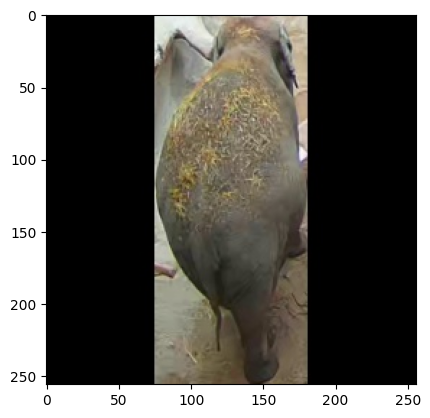

In [9]:
ds_transforms = tv.transforms.Compose([tv.transforms.PILToTensor(), transforms])
dataset_test = tv.datasets.ImageFolder(
    "/home/dherrera/data/elephants/identity/dataset/val", ds_transforms
)
print(dataset_test.class_to_idx)
ds_item, target = dataset_test[0]
if isinstance(ds_item, torch.Tensor):
    im = ds_item.permute([1, 2, 0]).numpy()
    im = im - np.mean(im)
    im = im - np.min(im)
    im = im / np.max(np.abs(im))
else:
    im = ds_item
plt.imshow(im)

In [10]:
inputs = torch.stack([ds_item, ds_item])
result = model.forward(inputs)
print(result)
print(target)
print(torch.argmax(result))

tensor([[ 0.7896,  0.8414, -1.8008,  3.3502, -3.1825],
        [ 0.7896,  0.8414, -1.8008,  3.3502, -3.1825]])
0
tensor(3)


In [11]:
from tqdm import tqdm

total = 0
correct = 0
for i in tqdm(range(0, len(dataset_test), 200)):
    ds_item, target = dataset_test[i]
    result = model.forward(ds_item[torch.newaxis, ...])
    y = torch.argmax(result).item()

    total += 1
    if y == target:
        correct += 1
accuracy = correct / total
print(f"Accuracy: {correct}/{total}={accuracy:%}")

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00, 55.47it/s]

Accuracy: 0/1=0.000000%


tensor([[ 1.3080,  0.2419,  0.2601, -1.7157,  0.1106]])

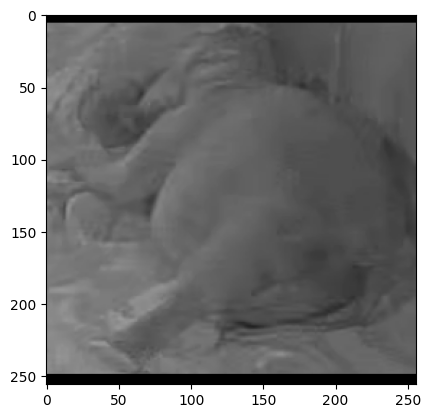

In [12]:
im = cv2.imread(PROJECT_ROOT / "debug/region0.png")
im = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)
plt.imshow(im)
im_tensor = torch.from_numpy(im.astype(np.float32) / 255).permute([2, 0, 1])[None, ...]
model.forward(im_tensor)
# -0.1497  2.8303 -0.9907 -0.6594 -0.9898
#  1.3874 -0.1803  0.9937 -2.1601 -0.0361

tensor([[-1.5954,  0.3738, -0.7324,  1.7657,  0.3160]])

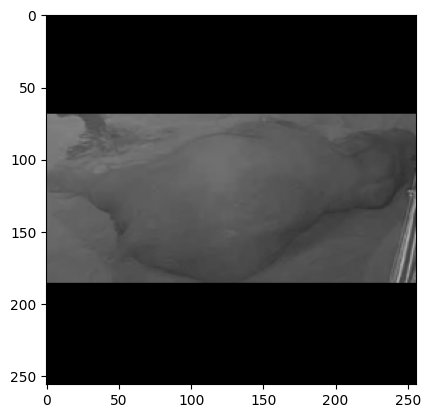

In [13]:
im = cv2.imread(PROJECT_ROOT / "debug/region1.png")
im = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)
plt.imshow(im)
im_tensor = torch.from_numpy(im.astype(np.float32) / 255).permute([2, 0, 1])[None, ...]
model.forward(im_tensor)
# -0.1497  2.8303 -0.9907 -0.6594 -0.9898
#  1.3874 -0.1803  0.9937 -2.1601 -0.0361